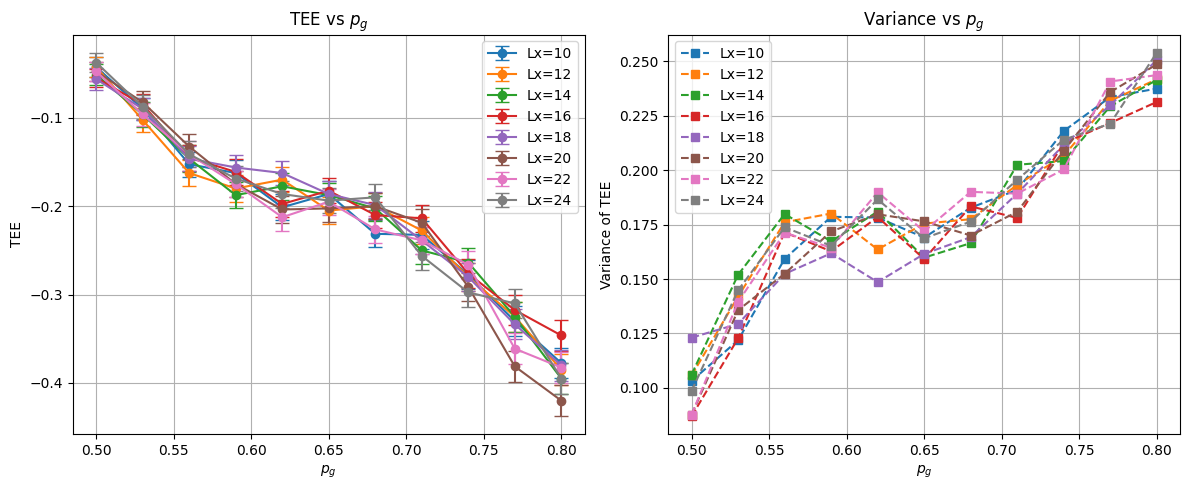

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob


cmap = plt.colormaps['gnuplot']
# npzファイルのパターン。Lxの値が変わる場合にマッチさせる
#files = glob.glob("Lx_*_MPI_results.npz")
files = glob.glob("px_0.2_Lx_*_MPI_results.npz")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

"""for file in files:

    data = np.load(file)
    # ファイル名からLxの値を抽出 (例: Lx_12_MPI_results.npz → 12)
    Lx_str = file.split("_")[3]  # '12'の部分
    Lx = int(Lx_str)
    #Lx_str = file.split("_")[1]  # '12'の部分
    #Lx = Lx_str"""

# --- Lxの値とファイル名をセットにして保持 ---
file_Lx_pairs = []
for file in files:
    try:
        Lx_str = file.split("_")[3]  # 'px_0.0_Lx_12_MPI_results.npz' → '12'
        Lx = int(Lx_str)
        file_Lx_pairs.append((Lx, file))
    except (IndexError, ValueError):
        print(f"ファイル名の形式が想定と異なります: {file}")

# --- Lxの昇順にソート ---
file_Lx_pairs.sort(key=lambda x: x[0])  # Lxの値で昇順ソート

for Lx, file in file_Lx_pairs:
    data = np.load(file)
    pg = data['pg']
    TEE_ave = data['TEE_ave']
    TEE_err = data['TEE_err']
    TEE_var = data['TEE_var']

    data.close()

    label = f"Lx={Lx}"
    # 左グラフ：TEEの平均値＋誤差バー
    ax[0].errorbar(pg, TEE_ave, yerr=TEE_err,fmt='o-', capsize=5, label=label)
    # 右グラフ：TEEの分散
    ax[1].plot(pg, TEE_var, 's--', label=label)

ax[0].set_xlabel('$p_g$')
ax[0].set_ylabel('TEE')
ax[0].set_title('TEE vs $p_g$')
ax[0].grid(True)
ax[0].legend()

ax[1].set_xlabel('$p_g$')
ax[1].set_ylabel('Variance of TEE')
ax[1].set_title('Variance vs $p_g$')
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.savefig("TEE_plot.png", dpi=300, bbox_inches='tight')
plt.show()


In [2]:
import numpy as np

data = np.load("px_0.0_Lx_12_MPI_results.npz")
print(data['pg'])
print(data['TEE_ave'])
print(data['TEE_err'])
print(data['TEE_var'])
data.close()

[0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
[ 0.01375  0.02375  0.025    0.0225  -0.00375 -0.19125 -0.49375 -0.68375
 -0.805   -0.91125 -0.99875]
[0.00411976 0.0053869  0.00679349 0.00949236 0.01219039 0.01870907
 0.01921361 0.01691974 0.01412775 0.01006073 0.00125   ]
[0.01356094 0.02318594 0.036875   0.07199375 0.11873594 0.27967344
 0.29496094 0.22873594 0.159475   0.08087344 0.00124844]


In [1]:
import numpy as np

data = np.load("px_0.0_Lx_12_MPI_results.npz")
print(data.files)  # 保存されているキーの一覧を表示
data.close()

['pg', 'TEE_ave', 'TEE_err', 'TEE_var']
